## **Importing Libraries & Parameter Setup**

In [1]:
!pip install pydub
!apt-get install ffmpeg

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
ffmpeg is already the newest version (7:4.4.2-0ubuntu0.22.04.1).
0 upgraded, 0 newly installed, 0 to remove and 34 not upgraded.


In [2]:
import os
import h5py
import librosa
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile
import shutil
import soundfile as sf
import pandas as pd
import random
import h5py
from google.colab import files
from pydub import AudioSegment
from tqdm import tqdm
from tensorflow.image import resize
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import Input, Conv2D, MaxPool2D, Dropout, Dense, Flatten, Reshape, Bidirectional, LSTM
from tensorflow.keras import Sequential
from tensorflow.keras import layers, models, backend as K
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.optimizers.schedules import CosineDecay
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.utils.class_weight import compute_class_weight

from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy('mixed_float16')

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
classes = ['rock', 'reggae', 'pop', 'metal', 'jazz', 'hiphop', 'disco', 'country', 'classical', 'blues']

## **All Data Set Melspectrogram**

In [5]:
dataSetPath = '/content/drive/MyDrive/GTZAN/Data/genres_original'
classes = ['rock', 'reggae', 'pop', 'metal', 'jazz', 'hiphop', 'disco', 'country', 'classical', 'blues']

In [ ]:
def MelspectrogramChunks(y, sr, targetShape, data, labels, iClass):
    chunkDuration = 4
    overlapDuration = 2

    chunkSamples = chunkDuration * sr
    overlapSamples = overlapDuration * sr

    numChunks = int(np.ceil((len(y) - chunkSamples) / (chunkSamples - overlapSamples))) + 1

    for i in range(numChunks):
        start = i * (chunkSamples - overlapSamples)
        end = start + chunkSamples
        chunk = y[start:end]

        start_time_sec = start / sr
        end_time_sec = end / sr

        spectrogram = librosa.feature.melspectrogram(y=chunk, sr=sr)

        resizedSpectrogram = resize(np.expand_dims(spectrogram, axis = -1), targetShape)

        data.append(resizedSpectrogram)
        labels.append(iClass)

In [ ]:
def loadAndPreprocessData(dataDir, classes, targetShape = (150, 150)):
  data = []
  labels = []

  for iClass, className in enumerate(classes):
    classDir = os.path.join(dataDir, className)
    print("Processing: ", className)
    for fileName in os.listdir(classDir):
      if fileName.endswith('.wav'):
        filePath = os.path.join(classDir, fileName)
        try:
          audioData, sampleRate = librosa.load(filePath, sr=None)
          MelspectrogramChunks(audioData, sampleRate, targetShape, data, labels, iClass)
        except Exception as e:
          print(f"Hata oluştu: {filePath} dosyası atlandı. Hata: {e}")
  return np.array(data), np.array(labels)

In [ ]:
data, labels = loadAndPreprocessData(dataSetPath, classes)

In [ ]:
labels = to_categorical(labels, num_classes = len(classes))

In [ ]:
np.save('/content/drive/My Drive/MUSIC GENRE CLASSIFICATION/GTZAN/CNN + BILSTM/data.npy', data)
np.save('/content/drive/My Drive/MUSIC GENRE CLASSIFICATION/GTZAN/CNN + BILSTM/labels.npy', labels)

## **Splitting Dataset into Training and Test Set**

In [ ]:
from sklearn.model_selection import train_test_split

XTrain, XTest, YTrain, YTest = train_test_split(data, labels, test_size = 0.2, random_state = 42)

In [ ]:
np.save('/content/drive/My Drive/MUSIC GENRE CLASSIFICATION/GTZAN/CNN + BILSTM/XTrain.npy', XTrain)
np.save('/content/drive/My Drive/MUSIC GENRE CLASSIFICATION/GTZAN/CNN + BILSTM/YTrain.npy', YTrain)
np.save('/content/drive/My Drive/MUSIC GENRE CLASSIFICATION/GTZAN/CNN + BILSTM/XTest.npy', XTest)
np.save('/content/drive/My Drive/MUSIC GENRE CLASSIFICATION/GTZAN/CNN + BILSTM/YTest.npy', YTest)

In [ ]:
XTrain[0].shape

(150, 150, 1)

## **Model Definition**

In [29]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D, MaxPool2D, Dropout, Flatten, Dense,
    Reshape, Bidirectional, LSTM, Input
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.layers import Layer, GlobalAveragePooling2D, Multiply
from tensorflow.keras.saving import register_keras_serializable
import tensorflow.keras.backend as K

In [30]:
class SEBlock(Layer):
    def __init__(self, ratio=8, **kwargs):
        super(SEBlock, self).__init__(**kwargs)
        self.ratio = ratio

    def build(self, input_shape):
        self.filters = input_shape[-1]
        self.global_pool = GlobalAveragePooling2D()
        self.dense1 = Dense(self.filters // self.ratio, activation='relu')
        self.dense2 = Dense(self.filters, activation='sigmoid')
        self.reshape = tf.keras.layers.Reshape((1, 1, self.filters))
        super(SEBlock, self).build(input_shape)

    def call(self, inputs):
        x = self.global_pool(inputs)
        x = self.dense1(x)
        x = self.dense2(x)
        x = self.reshape(x)
        return Multiply()([inputs, x])

In [31]:
@register_keras_serializable()
class Attention(Layer):
    def __init__(self, **kwargs):
        super(Attention, self).__init__(**kwargs)

    def build(self, input_shape):
        self.W = self.add_weight(name="att_weight", shape=(input_shape[-1], 1),
                                 initializer="normal")
        self.b = self.add_weight(name="att_bias", shape=(input_shape[1], 1),
                                 initializer="zeros")
        super().build(input_shape)

    def call(self, x):
        e = K.tanh(K.dot(x, self.W) + self.b)
        a = K.softmax(e, axis=1)
        output = x * a
        return K.sum(output, axis=1)


In [69]:
# --- Model ---
input_shape = (128, 128, 1)
num_classes = len(classes)

model = Sequential()

# --- CNN Blocks ---
model.add(Input(shape=input_shape))
model.add(Conv2D(32, 3, padding='same', activation='relu'))
model.add(Conv2D(32, 3, padding='same', activation='relu'))
model.add(MaxPool2D(2, 2))

model.add(Conv2D(64, 3, padding='same', activation='relu'))
model.add(Conv2D(64, 3, activation='relu'))
model.add(MaxPool2D(2, 2))
model.add(SEBlock())

model.add(Conv2D(128, 3, padding='same', activation='relu'))
model.add(Conv2D(128, 3, activation='relu'))
model.add(MaxPool2D(2, 2))

model.add(Dropout(0.3))

model.add(Conv2D(256, 3, padding='same', activation='relu'))
model.add(Conv2D(256, 3, activation='relu'))
model.add(MaxPool2D(2, 2))

model.add(Conv2D(512, 3, padding='same', activation='relu'))
model.add(Conv2D(512, 3, activation='relu'))
model.add(MaxPool2D(2, 2))

model.add(Dropout(0.3))

# --- LSTM Blocks ---
model.add(Flatten())
model.add(Reshape((4, 512)))

model.add(Bidirectional(LSTM(256, return_sequences=True)))
model.add(Dropout(0.25))
model.add(Bidirectional(LSTM(128, return_sequences=True)))
model.add(Dropout(0.25))

model.add(Attention())

# --- Fully Connected ---
model.add(Dense(512, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(num_classes, activation='softmax'))

# --- Model Özeti ---
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_34 (Conv2D)              │ (None, 128, 128, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_35 (Conv2D)              │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_36 (Conv2D)              │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_37 (Conv2D)              │ (None, 62, 62, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 31, 31, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ se_block_3 (SEBlock)            │ (None, 31, 31, 64)     │         1,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_38 (Conv2D)              │ (None, 31, 31, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_39 (Conv2D)              │ (None, 29, 29, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_40 (Conv2D)              │ (None, 14, 14, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_41 (Conv2D)              │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_42 (Conv2D)              │ (None, 6, 6, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_43 (Conv2D)              │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_21 (MaxPooling2D) │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_10 (Reshape)            │ (None, 4, 512)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_6 (Bidirectional) │ (None, 4, 512)         │     1,574,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 4, 512)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_7 (Bidirectional) │ (None, 4, 256)         │       656,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 4, 256)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ attention_3 (Attention)         │ (None, 256)            │           26

 Total params: 7,081,014 (27.01 MB)

 Trainable params: 7,081,014 (27.01 MB)

 Non-trainable params: 0 (0.00 B)

## **Model Compile**

In [70]:
model.compile(
    optimizer=Adam(learning_rate=0.0001, clipnorm=1.0),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

## **Model Train**

In [ ]:
data = np.load('/content/drive/My Drive/MUSIC GENRE CLASSIFICATION/GTZAN/CNN/data.npy')
labels = np.load('/content/drive/My Drive/MUSIC GENRE CLASSIFICATION/GTZAN/CNN/labels.npy')

In [6]:
XTrain = np.load('/content/drive/My Drive/MUSIC GENRE CLASSIFICATION/GTZAN/CNN/XTrain.npy')
YTrain = np.load('/content/drive/My Drive/MUSIC GENRE CLASSIFICATION/GTZAN/CNN/YTrain.npy')
XTest = np.load('/content/drive/My Drive/MUSIC GENRE CLASSIFICATION/GTZAN/CNN/XTest.npy')
YTest = np.load('/content/drive/My Drive/MUSIC GENRE CLASSIFICATION/GTZAN/CNN/YTest.npy')

In [71]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

train_datagen = ImageDataGenerator()
test_datagen = ImageDataGenerator()

train_generator = train_datagen.flow(XTrain, YTrain, batch_size=32)
test_generator = test_datagen.flow(XTest, YTest, batch_size=32)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

checkpoint = ModelCheckpoint(
    filepath='/content/drive/MyDrive/MUSIC GENRE CLASSIFICATION/GTZAN/CNN + BILSTM Advanced/best_model.keras',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

In [72]:
history = model.fit(
    train_generator,
    epochs=50,
    validation_data=test_generator,
    callbacks=[early_stop, checkpoint, reduce_lr],
    verbose=1
)

Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


374/375 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.2123 - loss: 2.1029
Epoch 1: val_loss improved from inf to 1.53866, saving model to /content/drive/MyDrive/MUSIC GENRE CLASSIFICATION/GTZAN/CNN + BILSTM Advanced/best_model.keras
375/375 ━━━━━━━━━━━━━━━━━━━━ 24s 37ms/step - accuracy: 0.2127 - loss: 2.1018 - val_accuracy: 0.4220 - val_loss: 1.5387 - learning_rate: 1.0000e-04
Epoch 2/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.4521 - loss: 1.4978
Epoch 2: val_loss improved from 1.53866 to 1.25396, saving model to /content/drive/MyDrive/MUSIC GENRE CLASSIFICATION/GTZAN/CNN + BILSTM Advanced/best_model.keras
375/375 ━━━━━━━━━━━━━━━━━━━━ 13s 34ms/step - accuracy: 0.4523 - loss: 1.4975 - val_accuracy: 0.5566 - val_loss: 1.2540 - learning_rate: 1.0000e-04
Epoch 3/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.5942 - loss: 1.1619
Epoch 3: val_loss improved from 1.25396 to 1.18299, saving model to /content/drive/MyDrive/MUSIC GENRE CLASSIFICATION/GTZAN/CNN + BILS

## **Model & Train History Save**

In [73]:
import json
with open('/content/drive/My Drive/MUSIC GENRE CLASSIFICATION/GTZAN/CNN + BILSTM Advanced/history.json', 'w') as f:
    json.dump(history.history, f)

In [74]:
from tensorflow.keras.models import load_model

model = load_model(
    '/content/drive/MyDrive/MUSIC GENRE CLASSIFICATION/GTZAN/CNN + BILSTM Advanced/best_model.keras',
    custom_objects={
        'SEBlock': SEBlock,
        'Attention': Attention
    }
)

In [75]:
import json

with open('/content/drive/My Drive/MUSIC GENRE CLASSIFICATION/GTZAN/CNN + BILSTM Advanced/history.json', 'r') as f:
    Training_History = json.load(f)

## **Model Evaluation**

In [76]:
trainLoss, trainAccuracy = model.evaluate(XTrain, YTrain)

375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9931 - loss: 0.0242


In [77]:
vallLoss, vallAccuracy = model.evaluate(XTest, YTest)

94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9012 - loss: 0.3796


In [59]:
eval_datagen = ImageDataGenerator()

train_eval_generator = eval_datagen.flow(XTrain, YTrain, batch_size=32)
test_eval_generator = eval_datagen.flow(XTest, YTest, batch_size=32)

trainLoss, trainAccuracy = model.evaluate(train_eval_generator)
valLoss, valAccuracy = model.evaluate(test_eval_generator)

print(f"Train Loss: {trainLoss}, Train Accuracy: {trainAccuracy}")
print(f"Validation Loss: {valLoss}, Validation Accuracy: {valAccuracy}")

375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9917 - loss: 0.0310
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9001 - loss: 0.3563
Train Loss: 0.03467845916748047, Train Accuracy: 0.9900667667388916
Validation Loss: 0.3831082880496979, Validation Accuracy: 0.8954924941062927


In [78]:
results_path = "/content/drive/My Drive/MUSIC GENRE CLASSIFICATION/GTZAN/CNN + BILSTM Advanced/evaluation_results.json"

evaluation_results = {
    "train_loss": trainLoss,
    "train_accuracy": trainAccuracy,
    "val_loss": vallLoss,
    "val_accuracy": vallAccuracy
}

with open(results_path, "w") as json_file:
    json.dump(evaluation_results, json_file, indent=4)

In [ ]:
results_path = "/content/drive/My Drive/MUSIC GENRE CLASSIFICATION/GTZAN/CNN + BILSTM/evaluation_results.json"

with open(results_path, "r") as json_file:
    evaluation_results = json.load(json_file)

trainLoss = evaluation_results["train_loss"]
trainAccuracy = evaluation_results["train_accuracy"]
valLoss = evaluation_results["val_loss"]
valAccuracy = evaluation_results["val_accuracy"]

## **Accuracy & Loss Visualization**

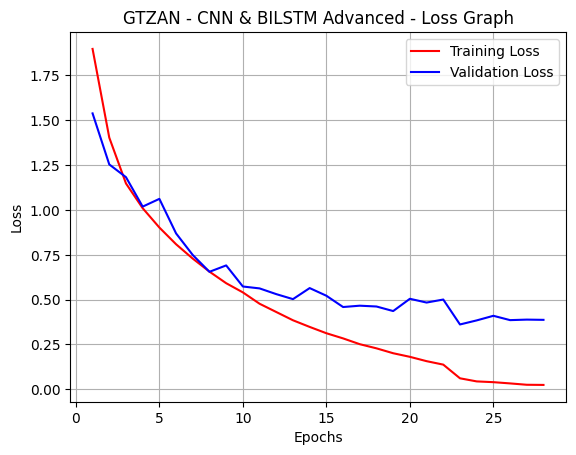

In [79]:
epochs = range(1, len(Training_History['loss']) + 1)

plt.plot(epochs, Training_History['loss'], label="Training Loss", color='red')
plt.plot(epochs, Training_History['val_loss'], label="Validation Loss", color='blue')

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("GTZAN - CNN & BILSTM Advanced - Loss Graph")
plt.legend()
plt.grid(True)
plt.show()


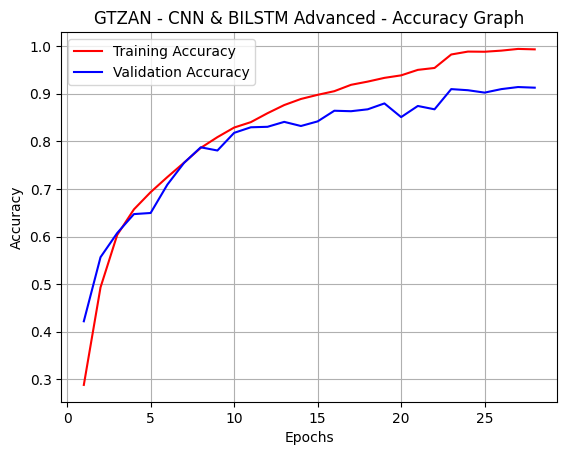

In [80]:
epochs = range(1, len(Training_History['accuracy']) + 1)

plt.plot(epochs, Training_History['accuracy'], label="Training Accuracy", color='red')
plt.plot(epochs, Training_History['val_accuracy'], label="Validation Accuracy", color='blue')

plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("GTZAN - CNN & BILSTM Advanced - Accuracy Graph")
plt.legend()
plt.grid(True)
plt.show()


## **Metrics**

In [81]:
YPred = model.predict(XTest)
print("YPred Shape:", YPred.shape)

94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step
YPred Shape: (2995, 10)


In [82]:
predictedCategories = np.argmax(YPred, axis=1)
trueCategories = np.argmax(YTest, axis=1)

In [83]:
print("Predicted Categories:", predictedCategories)
print("True Categories:", trueCategories)

Predicted Categories: [7 6 6 ... 0 1 4]
True Categories: [7 6 6 ... 0 1 4]


In [84]:
cm = confusion_matrix(trueCategories, predictedCategories)
print(classification_report(trueCategories, predictedCategories, target_names=classes))

              precision    recall  f1-score   support

        rock       0.83      0.84      0.83       301
      reggae       0.95      0.92      0.94       299
         pop       0.91      0.90      0.91       317
       metal       0.95      0.94      0.95       312
        jazz       0.93      0.92      0.93       277
      hiphop       0.96      0.93      0.95       313
       disco       0.94      0.91      0.92       301
     country       0.82      0.83      0.82       288
   classical       0.93      0.96      0.94       296
       blues       0.89      0.93      0.91       291

    accuracy                           0.91      2995
   macro avg       0.91      0.91      0.91      2995
weighted avg       0.91      0.91      0.91      2995



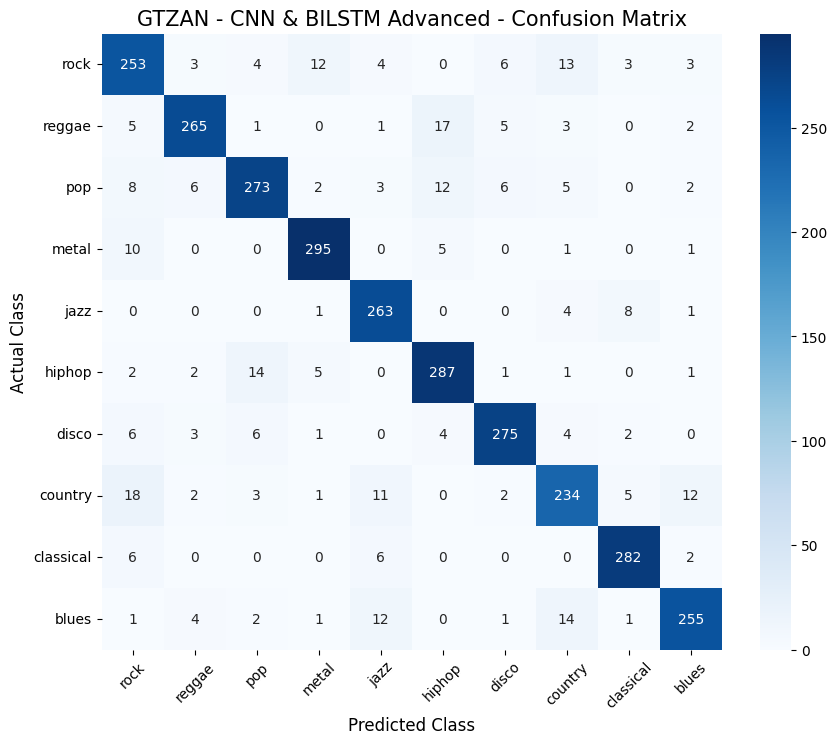

In [67]:
cm = confusion_matrix(trueCategories, predictedCategories)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=classes, yticklabels=classes)

plt.xlabel("Predicted Class", fontsize=12)
plt.ylabel("Actual Class", fontsize=12)
plt.title("GTZAN - CNN & BILSTM Advanced - Confusion Matrix", fontsize=15)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.show()

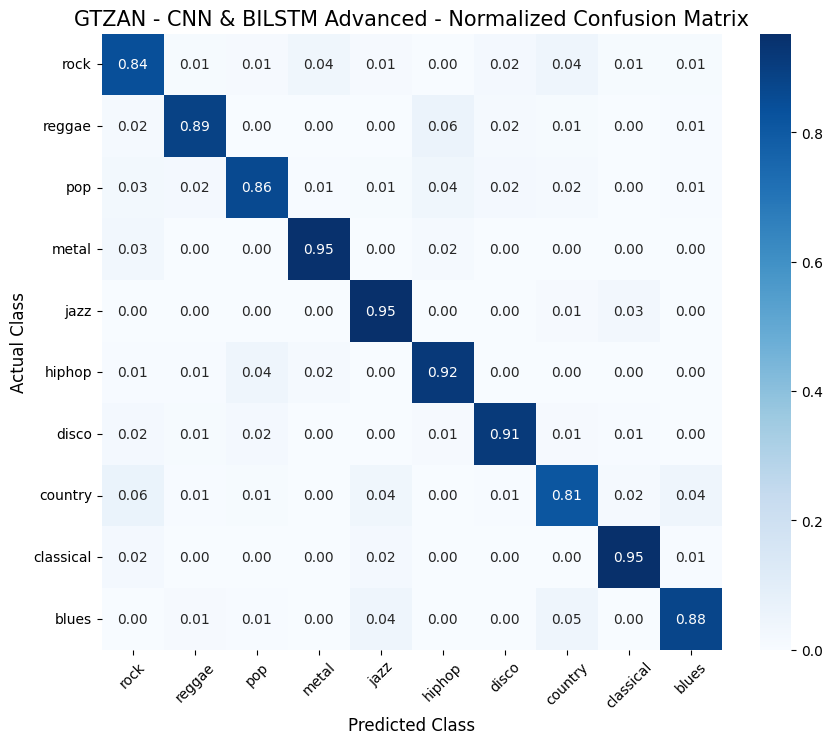

In [68]:
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(10, 8))
sns.heatmap(cm_normalized, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=classes, yticklabels=classes)

plt.title("GTZAN - CNN & BILSTM Advanced - Normalized Confusion Matrix", fontsize=15)
plt.xlabel("Predicted Class", fontsize=12)
plt.ylabel("Actual Class", fontsize=12)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.show()